# Examples of using fill-spill-merge

Examples of using fill-spill-merge as implemented in this repo with several postprocessing steps included:

- calling fill-spill-merge directly 
- using the wrapper in funcs (fsm)
- exploring the outputs of fsm
- plotting ideas

In [1]:
import sys
sys.path.insert(0, "/Users/jkingslake/Documents/science/meltwater_routing/fsm_pywrapper/fillspillmerge")
sys.path.insert(0, "../scripts")

from fillspillmerge import fill_spill_merge
import pdemtools as pdt
import rioxarray
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from funcs import fsm, cellArea

/Users/jkingslake/Documents/science/meltwater_routing/BFRN_meltwater/python/notebooks/../scripts/funcs.py:8: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


## Load a DEM from the REMA dataset. 
either from the internet or a version that's saved locally

In [2]:
# d = pdt.load.mosaic(
#     dataset='rema',  # must be `arcticdem` or `rema`
#     resolution=32,        # must be 2, 10, or 32
#     bounds=bounds,        # (xmin, ymin, xmax, ymax) or a shapely geometry
#     chunks = True
# )

ocean_value = 0.0

# d[0:1,:] = ocean_value 
# d[-1:,:] = ocean_value
# d[:,0:1] = ocean_value
# d[:,-1:] = ocean_value
# d = d.fillna(0)
# d.rio.to_raster('Nivlisen_32m_REMA.tif')

d = rioxarray.open_rasterio('Nivlisen_32m_REMA.tif').squeeze()

## Optionally coarsen the DEM

In [3]:
coarsen_factor = 4
d = d.coarsen(x=coarsen_factor, y=coarsen_factor, boundary='trim').mean()


## Add ocean around the edge of the DEM

In [4]:
ocean_value = 0.0

d[0:1,:] = ocean_value 
d[-1:,:] = ocean_value
d[:,0:1] = ocean_value
d[:,-1:] = ocean_value

## Calling fill-spill-merge directly
The simplest way to call fill-spill-merge is directly with an xarray melt field and the dem loaded above. For simplicity we can define a uniform melt field `m`. 


In [43]:
m = d*0+0.01
print(f"should result in a total melt of {m.sum().values * cellArea(d).values} m^3")

should result in a total melt of 76677088.0 m^3


In [44]:
w = fill_spill_merge(topography=d, wtd = m, ocean_level=ocean_value)
w

<xarray.DataArray 'water_depth' (y: 585, x: 800)> Size: 4MB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(585, 800))
Coordinates:
    band         int64 8B 1
  * x            (x) float64 6kB 3.858e+05 3.86e+05 ... 4.88e+05 4.881e+05
  * y            (y) float64 5kB 2.116e+06 2.116e+06 ... 2.042e+06 2.042e+06
    spatial_ref  int64 8B 0
Attributes:
    fillspillmerge_ocean_level:            0.0
    fillspillmerge_used_cached_hierarchy:  False
    long_name:                             water depth
    units:                                 m

`w` has the same dimensions as the dem `d` and the melt field `m`. The values in `w` are the total water depth at each pixel after it has been routed. 

Plotting it over the dem it helps to mask all the areas where the `w`.

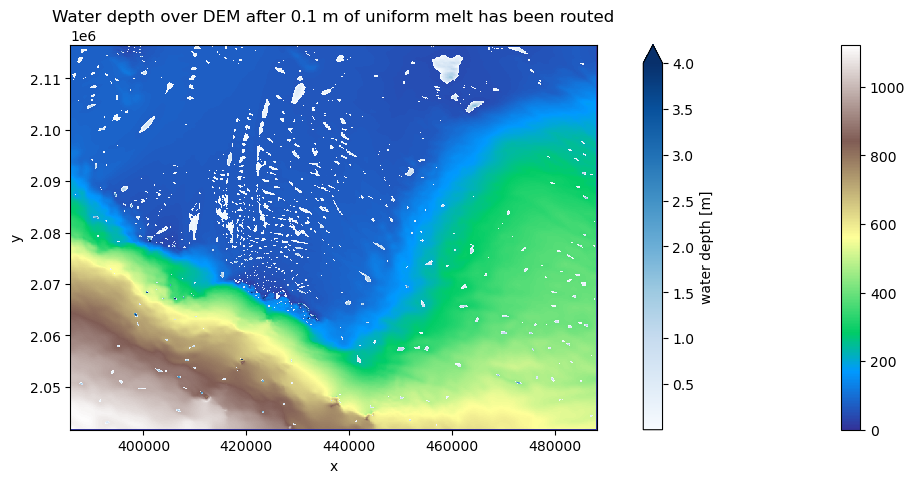

In [45]:
d.plot(cmap='terrain', figsize=(15, 5))
w.where(w>0).plot(cmap='Blues', vmax=4)
plt.title('Water depth over DEM after 0.1 m of uniform melt has been routed')
plt.gca().set_aspect('equal') 


## Using the wrapper in funcs (fsm)

There is a function in funcs which call the fsm algorithm and returns the results in a xarray dataset along with some postprocessed quantities, e.g., the center of mass of the water and the distance between this and the center of mass of the melt. 

In [46]:
from funcs import fsm, cellArea

In [47]:
ds = fsm(d, m)

In [48]:
ds

<xarray.Dataset> Size: 15MB
Dimensions:                       (x: 800, y: 585)
Coordinates:
  * x                             (x) float64 6kB 3.858e+05 ... 4.881e+05
  * y                             (y) float64 5kB 2.116e+06 ... 2.042e+06
    spatial_ref                   int64 8B 0
Data variables: (12/16)
    water_depth                   (y, x) float64 4MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    melt                          (y, x) float32 2MB 0.01 0.01 ... 0.01 0.01
    dem                           (y, x) float32 2MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    x_com_w                       float64 8B 4.355e+05
    y_com_w                       float64 8B 2.084e+06
    x_com_m                       float64 8B 4.37e+05
    ...                            ...
    accumulation_on_grounded_ice  float64 8B 3.272e+07
    melt_on_grounded_ice          float64 8B 4.743e+07
    water_flow_over_GL            float64 8B 1.471e+07
    grounded_mask                 (y, x) int64 4MB 0 0 0 0 0 0 0 ... 1 1 1 1 1 1
    accumulation_total            float64 8B 7.122e+07
    melt_total                    float64 8B 7.668e+07
Attributes:
    fillspillmerge_ocean_level:            0.0
    fillspillmerge_used_cached_hierarchy:  True
    long_name:                             water depth
    units:                                 m

## Explore the outputs of fsm
THe outputs of fsm include attrs that (hopefully) describes what each one is. Below are some examples of plot you can make with these outputs. 

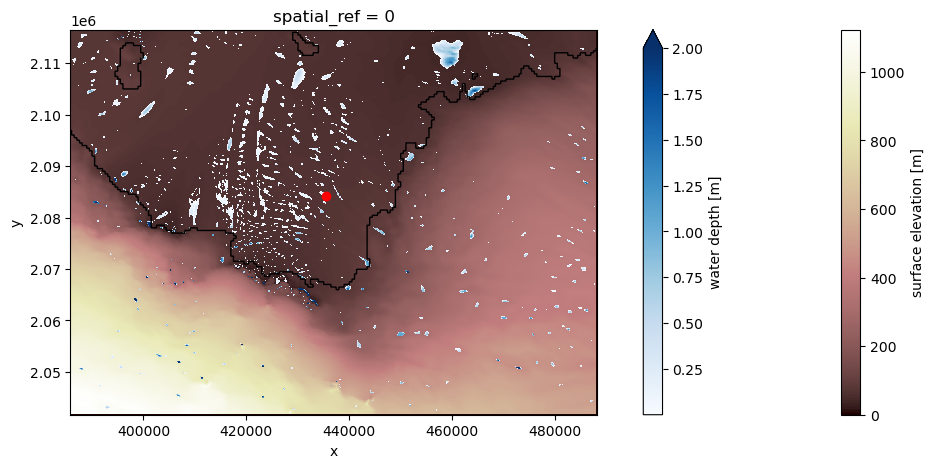

In [49]:
# dem
ds.dem.plot(cmap='pink', figsize=(15, 5))
# grounding line
ds.grounded_mask.plot.contour(levels=[0.5], colors='k', linewidths=1)
# routed water depth
ds.water_depth.where(ds.water_depth>0).plot(cmap='Blues', vmax=2)
# center of mass of the water
plt.scatter(ds.x_com_w.values, ds.y_com_w.values, color='red', marker = 'o', label='Water COM')
plt.gca().set_aspect('equal')

The xr.dataset also includes calculations of the total water on the grounded ice and in the whole raster.

In [57]:
print(f"Total melt volume: {ds.melt_total.values:.2e} m^3") #in scientific notation
print(f"Total accumulated water after routing : {ds.accumulation_total.values:.2e} m^3. Which is slightly less than the melt \n because some has flowed into the ocean. ")
print(f"Total melt on grounded ice: {ds.melt_on_grounded_ice.values:.2e} m^3")
print(f"Total accumulated water on grounded ice: {ds.accumulation_on_grounded_ice.values:.2e} m^3")
print(f"Total volume of water that has flowed over the grounding line: {ds.water_flow_over_GL.values:.2e} m^3")
print('----')
print(f"The total response of the grounding line flux to the changes in ice shelf thickness that this routing led to: {ds.total_GL_flux_response.values:.2e} kg/yr")

Total melt volume: 7.67e+07 m^3
Total accumulated water after routing : 7.12e+07 m^3. Which is slightly less than the melt 
 because some has flowed into the ocean. 
Total melt on grounded ice: 4.74e+07 m^3
Total accumulated water on grounded ice: 3.27e+07 m^3
Total volume of water that has flowed over the grounding line: 1.47e+07 m^3
----
The total response of the grounding line flux to the changes in ice shelf thickness that this routing led to: 3.15e+07 kg/yr


## Resusing the depression heirachy. 
For a lot of applications, the depression hierarchy doesnt need to change between calls to fsm. So you can compute it when you load the DEM and us it each time. This seriously speeds things up.

In [12]:
_, dh = fill_spill_merge(
    topography=d,
    ocean_level=0.0,
    return_hierarchy=True,
)

In [ ]:
ds = fsm(dem = d, melt = m, dh =dh)

In [35]:
ds

<xarray.Dataset> Size: 17MB
Dimensions:                       (x: 800, y: 585)
Coordinates:
  * x                             (x) float64 6kB 3.858e+05 ... 4.881e+05
    spatial_ref                   int64 8B 0
  * y                             (y) float64 5kB 2.116e+06 ... 2.042e+06
Data variables: (12/16)
    water_depth                   (y, x) float64 4MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    melt                          (y, x) float64 4MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    dem                           (y, x) float32 2MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    x_com_w                       float64 8B 4.484e+05
    y_com_w                       float64 8B 2.101e+06
    x_com_m                       float64 8B 4.37e+05
    ...                            ...
    accumulation_on_grounded_ice  float64 8B 6.594e+06
    melt_on_grounded_ice          float64 8B 0.0
    water_flow_over_GL            float64 8B -6.594e+06
    grounded_mask                 (y, x) int64 4MB 0 0 0 0 0 0 0 ... 1 1 1 1 1 1
    accumulation_total            float64 8B 7.848e+07
    melt_total                    float64 8B 7.848e+07
Attributes:
    units:                                 m
    long_name:                             water depth
    description:                           the surface melt as a function of ...
    fillspillmerge_ocean_level:            0.0
    fillspillmerge_used_cached_hierarchy:  True

## Using other melt fields
For example, here are reuslts from using melt field witha region of non-zero melt in the center. 

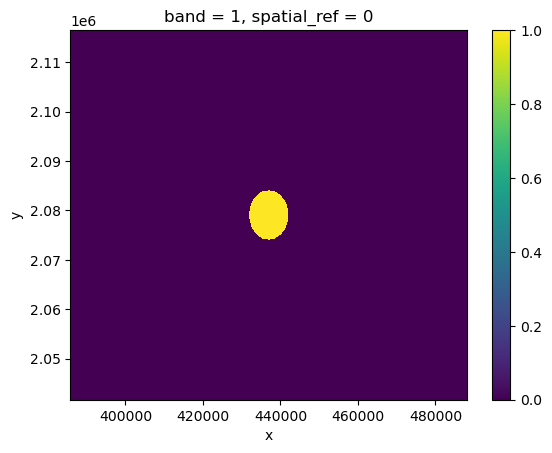

In [31]:
center_x = d.x.mean().values
center_y = d.y.mean().values

region_size = 5000
circular_mask = (np.abs(d.x - center_x)**2 + (np.abs(d.y - center_y)**2) < region_size**2).transpose(*d.dims)

circular_melt = xr.where(circular_mask, 1, 0.0)

circular_melt.plot()

/Users/jkingslake/.local/share/mamba/envs/pdem_tools/lib/python3.13/site-packages/xarray/plot/dataarray_plot.py:2007: UserWarning: The following kwargs were not used by contour: 'label'
  primitive = ax.contour(x, y, z, **kwargs)


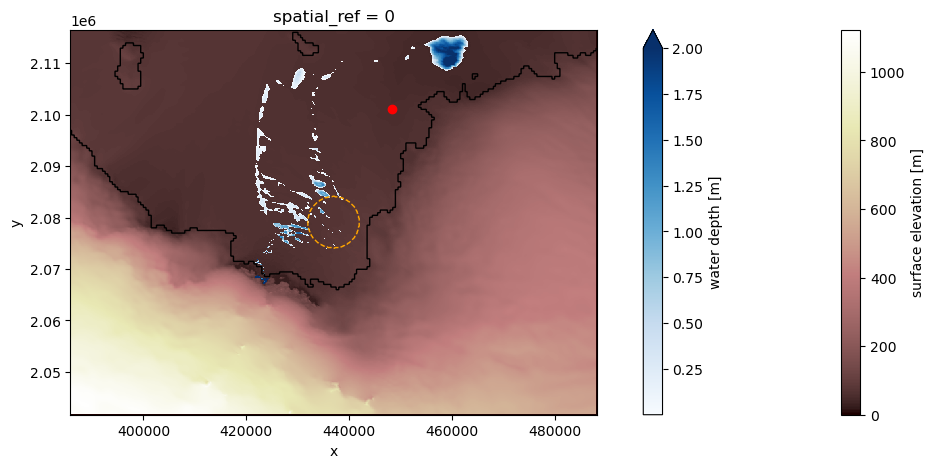

In [42]:
ds = fsm(dem = d, melt = circular_melt, dh =dh)

ds.dem.plot(cmap='pink', figsize=(15, 5))
# grounding line
ds.grounded_mask.plot.contour(levels=[0.5], colors='k', linewidths=1)
# routed water depth
ds.water_depth.where(ds.water_depth>0).plot(cmap='Blues', vmax=2)
# center of mass of the water
plt.scatter(ds.x_com_w.values, ds.y_com_w.values, color='red', marker = 'o', label='Water COM')
# melt field contour
ds.melt.plot.contour(levels=[0.5], colors='orange', linewidths=1, linestyles='dashed', label='Melt field contour')
plt.gca().set_aspect('equal')

In [34]:
ds.melt_on_grounded_ice.values

array(0.)